In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.ensemble import IsolationForest

In [14]:
# load the dataset
df = pd.read_csv('embedded_system_network_security_dataset.csv')

In [15]:
df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,False,True,True,False,False,False,False,False,False
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,False,True,False,False,False,True,False,True,False
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,False,True,False,False,True,False,False,False,False
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,False,False,False,True,False,False,False,False,False
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,True,False,False,True,False,False,False,True,False


In [16]:
# check for missing values
df.isnull().sum()

packet_size              0
inter_arrival_time       0
src_port                 0
dst_port                 0
packet_count_5s          0
mean_packet_size         0
spectral_entropy         0
frequency_band_energy    0
label                    0
protocol_type_TCP        0
protocol_type_UDP        0
src_ip_192.168.1.2       0
src_ip_192.168.1.3       0
dst_ip_192.168.1.5       0
dst_ip_192.168.1.6       0
tcp_flags_FIN            0
tcp_flags_SYN            0
tcp_flags_SYN-ACK        0
dtype: int64

In [17]:
# columns in the dataset
df.columns

Index(['packet_size', 'inter_arrival_time', 'src_port', 'dst_port',
       'packet_count_5s', 'mean_packet_size', 'spectral_entropy',
       'frequency_band_energy', 'label', 'protocol_type_TCP',
       'protocol_type_UDP', 'src_ip_192.168.1.2', 'src_ip_192.168.1.3',
       'dst_ip_192.168.1.5', 'dst_ip_192.168.1.6', 'tcp_flags_FIN',
       'tcp_flags_SYN', 'tcp_flags_SYN-ACK'],
      dtype='object')

In [18]:
# data preprocessing
# drop the label column
df = df.drop('label', axis=1)


In [19]:
df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,False,True,True,False,False,False,False,False,False
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,False,True,False,False,False,True,False,True,False
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,False,True,False,False,True,False,False,False,False
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,False,False,False,True,False,False,False,False,False
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,True,False,False,True,False,False,False,True,False


In [20]:
# if columns is bool type, convert it to int
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)
df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0,1,1,0,0,0,0,0,0
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0,1,0,0,0,1,0,1,0
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0,1,0,0,1,0,0,0,0
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0,0,0,1,0,0,0,0,0
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,1,0,0,1,0,0,0,1,0


In [21]:
# scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features = scaler.fit_transform(df)

In [22]:
# convert the scaled features back to a dataframe
scaled_features_df = pd.DataFrame(features, columns=df.columns)
scaled_features_df.head()

,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,-0.336115,0.384724,1.650011,1.351370,1.155602,0.0,1.157333,0.166460,-0.671847,1.347925,1.471243,-0.714545,-0.712949,-0.722544,-0.57889,-0.554247,-0.585049
1,0.086758,0.815080,1.477849,1.351370,0.919957,0.0,-1.188696,1.707564,-0.671847,1.347925,-0.679697,-0.714545,-0.712949,1.383999,-0.57889,1.804250,-0.585049
2,-0.954350,-0.096598,1.807479,-0.665426,-0.729556,0.0,1.229489,-1.534356,-0.671847,1.347925,-0.679697,-0.714545,1.402626,-0.722544,-0.57889,-0.554247,-0.585049
3,0.245026,-0.218135,1.063244,-0.815436,-1.200846,0.0,-1.168120,-1.067234,-0.671847,-0.741881,-0.679697,1.399493,-0.712949,-0.722544,-0.57889,-0.554247,-0.585049
4,0.514577,1.339842,-0.276022,-0.815436,0.684312,0.0,1.464215,0.224480,1.488433,-0.741881,-0.679697,1.399493,-0.712949,-0.722544,-0.57889,1.804250,-0.585049


In [23]:
# initialize the parameters for isolation forest
n_estimators = 100  # number of trees in the forest
contamination = 'auto'  # proportion of anomalies in the dataset
max_samples = 'auto'  # number of samples to draw from the dataset to train each tree
random_state = 42  # random seed for reproducibility

# train the isolation forest model
model = IsolationForest(n_estimators=n_estimators, contamination=contamination, max_samples=max_samples, random_state=random_state)
model.fit(scaled_features_df)

anomoly_scores = model.decision_function(scaled_features_df)
anomoly_scores.shape


(1000,)

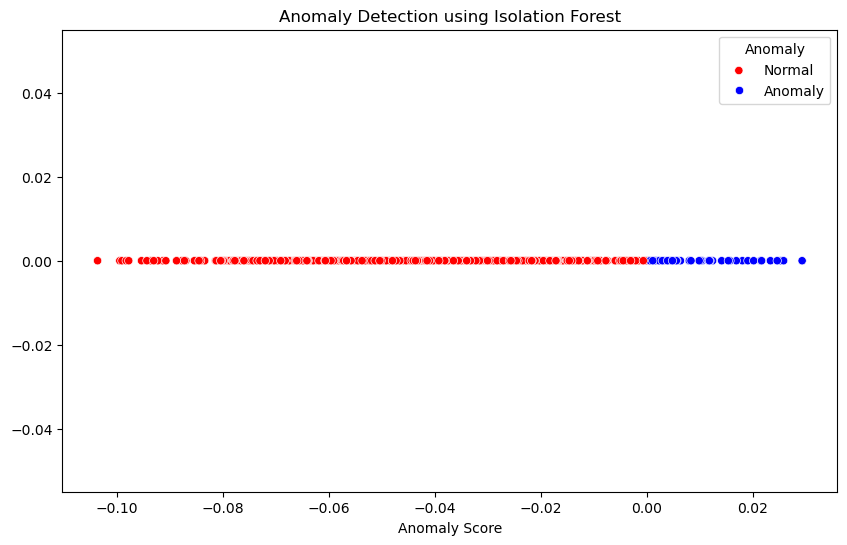

In [25]:
# visualize the anomalies using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=anomoly_scores, y=np.zeros_like(anomoly_scores), hue=anomoly_scores < 0, palette={True: 'red', False: 'blue'})
plt.title('Anomaly Detection using Isolation Forest')
plt.xlabel('Anomaly Score')
plt.ylabel('')
plt.legend(title='Anomaly', labels=['Normal', 'Anomaly'])
plt.show()


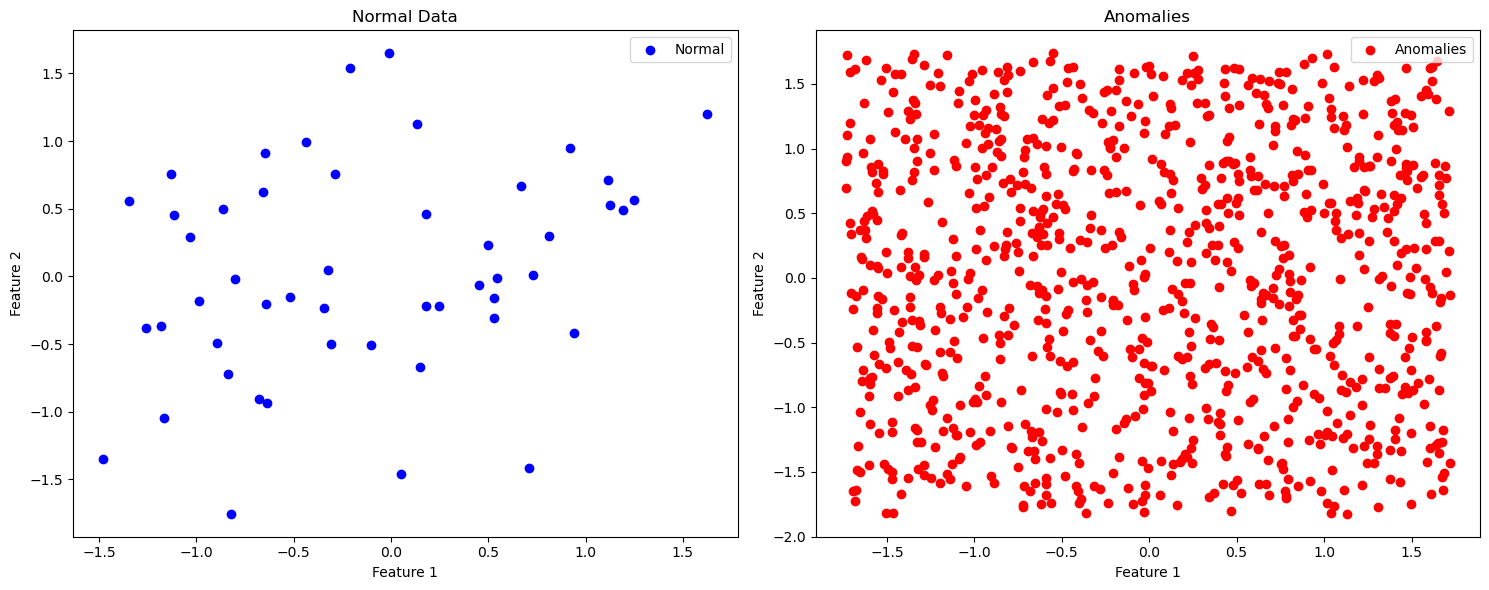

In [26]:
fig, axes=plt.subplots(1, 2, figsize=(15, 6))
normal=scaled_features_df[anomoly_scores >= 0]
anomalies=scaled_features_df[anomoly_scores < 0]
axes[0].scatter(normal.iloc[:, 0], normal.iloc[:, 1], color='blue', label='Normal')
axes[0].set_title('Normal Data')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()
axes[1].scatter(anomalies.iloc[:, 0], anomalies.iloc[:, 1], color='red', label='Anomalies')
axes[1].set_title('Anomalies')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()
plt.tight_layout()
plt.show()